In [1]:
%pip install aiohttp

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Ana Khan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import time
import aiohttp
import urllib.parse
from IPython.display import Image, display

In [3]:
subscriptionKey = "5vcT0jcYbEnC1CzNnV6iLthtWGebUvJQst75hLtO0aamNnJwMUWwJQQJ99CFACYeBjF4YdtHAAAgAZMP1AZz"
currentLocation = [34.028115, -118.5184279]
session = aiohttp.ClientSession()

# Parameters for the vehicle consumption model
travelMode = "car"
vehicleEngineType = "electric"
currentChargeInkWh = 45
maxChargeInkWh = 80
timeBudgetInSec = 550
routeType = "eco"
constantSpeedConsumptionInkWhPerHundredkm = "50,8.2:130,21.3"

# Get boundaries for the electric vehicle's reachable range.
routeRangeResponse = await (await session.get("https://atlas.microsoft.com/route/range/json?subscription-key={}&api-version=1.0&query={}&travelMode={}&vehicleEngineType={}&currentChargeInkWh={}&maxChargeInkWh={}&timeBudgetInSec={}&routeType={}&constantSpeedConsumptionInkWhPerHundredkm={}"
                                              .format(subscriptionKey, str(currentLocation[0])+","+str(currentLocation[1]), travelMode, vehicleEngineType, currentChargeInkWh, maxChargeInkWh, timeBudgetInSec, routeType, constantSpeedConsumptionInkWhPerHundredkm))).json()

polyBounds = routeRangeResponse["reachableRange"]["boundary"]

for i in range(len(polyBounds)):
    coordList = list(polyBounds[i].values())
    coordList[0], coordList[1] = coordList[1], coordList[0]
    polyBounds[i] = coordList

polyBounds.pop()
polyBounds.append(polyBounds[0])

boundsData = {
    "geometry": {
        "type": "Polygon",
        "coordinates":
        [
            polyBounds
        ]
    }
}

In [4]:
# Search for electric vehicle stations within reachable range.
searchPolyResponse = await (await session.post(url="https://atlas.microsoft.com/search/geometry/json?subscription-key={}&api-version=1.0&query=electric vehicle station&idxSet=POI&limit=50".format(subscriptionKey), json=boundsData)).json()

reachableLocations = []
for loc in range(len(searchPolyResponse["results"])):
    location = list(searchPolyResponse["results"][loc]["position"].values())
    location[0], location[1] = location[1], location[0]
    reachableLocations.append(location)

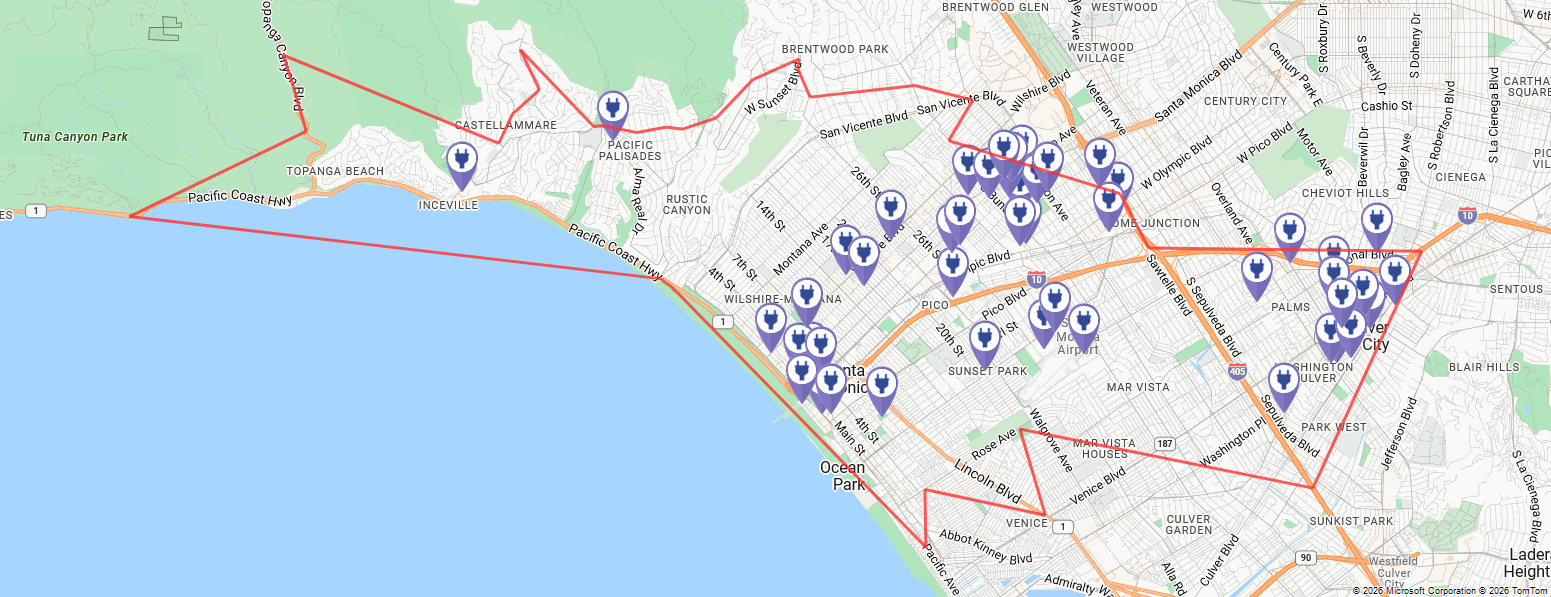

In [5]:
# Get boundaries for the bounding box.
def getBounds(polyBounds):
    maxLon = max(map(lambda x: x[0], polyBounds))
    minLon = min(map(lambda x: x[0], polyBounds))

    maxLat = max(map(lambda x: x[1], polyBounds))
    minLat = min(map(lambda x: x[1], polyBounds))

    # Buffer the bounding box by 10 percent to account for the pixel size of pins at the ends of the route.
    lonBuffer = (maxLon-minLon)*0.1
    minLon -= lonBuffer
    maxLon += lonBuffer

    latBuffer = (maxLat-minLat)*0.1
    minLat -= latBuffer
    maxLat += latBuffer

    return [minLon, maxLon, minLat, maxLat]


minLon, maxLon, minLat, maxLat = getBounds(polyBounds)
polyBoundsFormatted = ('|'.join(map(str, polyBounds))).replace(
    '[', '').replace(']', '').replace(',', '')
reachableLocationsFormatted = ('|'.join(map(str, reachableLocations))).replace(
    '[', '').replace(']', '').replace(',', '')

path = "lcff3333|lw3|la0.80|fa0.35||{}".format(polyBoundsFormatted)
pins = "custom|an15 53||{}||https://raw.githubusercontent.com/Azure-Samples/AzureMapsCodeSamples/e3a684e7423075129a0857c63011e7cfdda213b7/Static/images/icons/ev_pin.png".format(
    reachableLocationsFormatted)

encodedPins = urllib.parse.quote(pins, safe='')

# Render the range and electric vehicle charging points on the map.
staticMapResponse = await session.get("https://atlas.microsoft.com/map/static?api-version=2024-04-01&subscription-key={}&pins={}&path={}&bbox={}&zoom=12".format(subscriptionKey, encodedPins, path, str(minLon)+", "+str(minLat)+", "+str(maxLon)+", "+str(maxLat)))

poiRangeMap = await staticMapResponse.content.read()

display(Image(poiRangeMap))